In [1]:
pip install tf-models-official==2.11.3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 32.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 352.1/352.1 kB 19.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 5.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 11.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.6/240.6 kB 19.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 636.6/636.6 kB 46.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 56.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.9/238.9 kB 20.2 MB/s eta 0:00:00
  Created wheel for pycocotools: filename=pycocotools-2.0.6-cp37-cp37m-linux_x86_64.whl siz

In [2]:
!pip install pipreqs

In [3]:
pip install imutils

  Preparing metadata (setup.py) ... done
  Created wheel for imutils: filename=imutils-0.5.4-py3-none-any.whl size=25861 sha256=a2d3df0b4056fe40a41e4f520161e6d82d4648b363863c2994d003fc3a4c9be3
  Stored in directory: /root/.cache/pip/wheels/35/e4/69/cb99d996d14a2971b79b990d68b05a17d58ce530ff96090dfc
Successfully built imutils
Note: you may need to restart the kernel to use updated packages.


In [4]:
!pip install wandb --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 31.1 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: wandb
    Found existing installation: wandb 0.14.0
    Uninstalling wandb-0.14.0:
      Successfully uninstalled wandb-0.14.0


# Import Packages

In [6]:
import os
import sys
import math
import random
import gc
import numpy as np
import cv2
import imutils

from matplotlib import pyplot as plt
%matplotlib inline
from matplotlib import rcParams
import seaborn as sns
from PIL import Image
from imageio import imwrite
import seaborn as sns


import tensorflow as tf
import tensorflow_models as tfm
import tensorflow_probability as tfp

from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.applications import (
    InceptionResNetV2,
    ResNet50,
    InceptionV3,
#     DenseNet121,
)
# from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.layers import Input, Dense, Dropout, Flatten, GlobalAveragePooling1D, GlobalAveragePooling2D, LeakyReLU, BatchNormalization
from tensorflow.keras.losses import BinaryCrossentropy, categorical_crossentropy
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, CSVLogger, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, SGD, Adamax
from tensorflow.keras.applications.imagenet_utils import preprocess_input
from tensorflow.keras.metrics import Accuracy, Precision, Recall, AUC, TopKCategoricalAccuracy, TruePositives, FalsePositives, TrueNegatives, FalseNegatives

from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical




Imported


# File Links

In [8]:


path = '/kaggle/input/brain-tumor-detection-mri/Brain_Tumor_Detection' # Dataset 3

model_dir = '/kaggle/input/radimagenet-irv2/RadImageNet-IRV2_notop.h5'

CODE_OUTPUTS = '/kaggle/working/'
csv_logger = CSVLogger(f'{CODE_OUTPUTS}training.log')

# Helper Functions

In [10]:
def display_images(images, name):
#     Display 9 Images
    for i in range(9):
        # define subplot
        plt.subplot(3, 3, 1 + i)
        plt.axis("off")
        # plot single image
        image = images[i, :, :, 0]
        plt.imshow(image, cmap="gray")
        plt.savefig(
            f'{CODE_OUTPUTS}{name}image.jpg',
            dpi=300,
            transparent=True,
        )
    plt.show()
    plt.close()
    
def visualize_distribution(images1, images2, count):
    fig, axs = plt.subplots(ncols=1, nrows=1, figsize=(18, 10))

    images1 = images1[:count]
    sns.distplot(images1, label="Real Images", hist=True, color="#fc0328", ax=axs)
    if images2 != None:
        images2 = images2[:count]
        sns.distplot(images2, label="Generated Images", hist=True, color="#0c06c7", ax=axs)
    axs.legend(loc="upper right", prop={"size": 12})
    pyplot.savefig(
        distribution,
        bbox_inches="tight",
        transparent=True,
    )
    plt.show()
    plt.close()

def visualize_class_distribution(classes, name):
    fig, axs = plt.subplots(ncols=1, nrows=1, figsize=(18, 10))
    sns.distplot(classes, label= name, hist=True, color="#fc0328", ax=axs)
    plt.savefig(
        f"class_distribution_{name}.jpg",
        bbox_inches="tight",
        transparent=True,
        dpi= 300,
    )
    plt.show()
    plt.close()
    
def bytes_to_megabytes(bytes):
    megabytes = bytes / (1024 * 1024)
    return megabytes


# Variables Setup

In [11]:

LATENT_DIM = 100
DISPLAY_GENRATED_SAMPLES = 10
BATCH_SIZE = 32
IMAGE_SIZE = 128

TRAIN_RATIO = 0.80
VALIDATION_RATIO = 0.10
TEST_RATIO = 0.10

CLASSIC_AUG = False
GAN_AUG = False
MIXUP_AUG = False


Before defining variables:


# Preprocessing & Enhancement

In [12]:
def crop_image(image_to_crop):
    img_size = image_to_crop.shape
   
    gray = cv2.cvtColor(image_to_crop, cv2.COLOR_RGB2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    # threshold the image, then perform a series of erosions +
    # dilations to remove any small regions of noise
    thresh = cv2.threshold(gray, 20, 255, cv2.THRESH_BINARY)[1]
    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)

    # find contours in thresholded image, then grab the largest one
    cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = imutils.grab_contours(cnts)
    c = max(cnts, key=cv2.contourArea)

    # find the extreme points
    extLeft = tuple(c[c[:, :, 0].argmin()][0])
    extRight = tuple(c[c[:, :, 0].argmax()][0])
    extTop = tuple(c[c[:, :, 1].argmin()][0])
    extBot = tuple(c[c[:, :, 1].argmax()][0])

    # add contour on the image
    img_cnt = cv2.drawContours(image_to_crop.copy(), [c], -1, (0, 255, 255), 4)
    
    # add extreme points
    img_pnt = cv2.circle(img_cnt.copy(), extLeft, 8, (0, 0, 255), -1)
    img_pnt = cv2.circle(img_pnt, extRight, 8, (0, 255, 0), -1)
    img_pnt = cv2.circle(img_pnt, extTop, 8, (255, 0, 0), -1)
    img_pnt = cv2.circle(img_pnt, extBot, 8, (255, 255, 0), -1)

    # crop
    ADD_PIXELS = 0
    Cropped_image = image_to_crop[extTop[1]-ADD_PIXELS:extBot[1]+ADD_PIXELS, extLeft[0]-ADD_PIXELS:extRight[0]+ADD_PIXELS].copy()
    return Cropped_image
def Enhancement(image):
    
    NOISE_FLOOR = 20

    def reduce_noise(noisy_img, noise_floor=NOISE_FLOOR):

        clean_img = noisy_img
        clean_img[noisy_img < NOISE_FLOOR] = 0
        return clean_img

    def eualize_darken(image):        
        new_img = cv2.bilateralFilter(image,1,10,10)
        img_hsv = cv2.cvtColor(new_img, cv2.COLOR_RGB2YCrCb)
        img_hsv[:, :, 0] = cv2.equalizeHist(img_hsv[:, :, 0])
        image = cv2.cvtColor(img_hsv, cv2.COLOR_YCrCb2RGB)  
        return image


    def gammaCorrection(src, gamma):
        image = src.astype(np.float32) / 255.0
        # Perform gamma correction
        gamma_corrected = np.power(image, gamma)
        # Convert the gamma-corrected image back to uint8
        image = (gamma_corrected * 255).clip(0, 255).astype(np.uint8)
        return image
    image = reduce_noise(image)
    image = eualize_darken(image)
    image = gammaCorrection(image, 1.6)
    
    return image

# Import Data

There are 1500 samples in the class yes
There are 1500 samples in the class no
Images:  (3000, 128, 128, 3)
Labels:  (3000,)
Images size:140.6251449584961, labels: 0.02298736572265625 


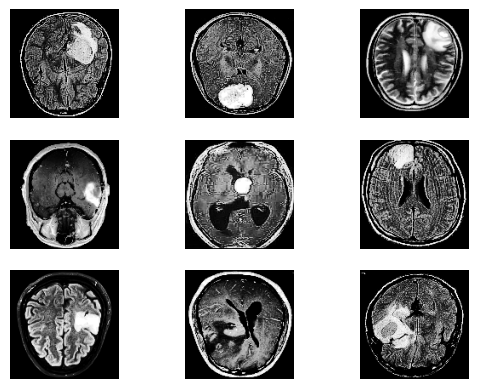

In [13]:
Images = []
Labels = []
Classes = ['yes', 'no']
classes_dict = {'yes': 0, 'no':1}

for Class in classes_dict.keys():
    class_samples = 0
    cpath = os.path.join(path, Class)
    cpath += '/'
     for img in os.listdir(cpath):
        class_samples += 1

        image = cv2.imread(os.path.join(cpath, img), cv2.IMREAD_COLOR)     
        image = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE))
        image = Enhancement(image)
        
        Images.append(image)
        Labels.append(classes_dict[Class])
    print(f"There are {class_samples} samples in the class {Class}")

Images = np.array(Images)
Labels = np.array(Labels)

print("Images: ", Images.shape)
print("Labels: ", Labels.shape)

imgs = bytes_to_megabytes(sys.getsizeof(Images))
lbls = bytes_to_megabytes(sys.getsizeof(Labels))
print(f"Images size:{imgs}, labels: {lbls} ")

display_images(Images, 'data_import')
visualize_distribution(Images, None, 20)

# Split data 75:15:15

In [15]:
x_train, x_val_tmp, y_train, y_val_tmp = train_test_split(Images, Labels, test_size= 1 - TRAIN_RATIO, random_state= 16, shuffle= True, stratify= Labels)

x_val, x_test, y_val, y_test = train_test_split(x_val_tmp, y_val_tmp, test_size=TEST_RATIO/(TEST_RATIO + VALIDATION_RATIO), random_state= 16, shuffle= True, stratify= y_val_tmp) 

print("x_train: ", x_train.shape)
print("x_val: ", x_val.shape)
print("x_test: ", x_test.shape)

# Calculate the mean and standard deviation of the training set only
train_means = np.mean(x_train, axis=(0, 1, 2))
train_stdevs = np.std(x_train, axis=(0, 1, 2))

# Normalize all sets using the training set statistics
x_train = (x_train - train_means) / train_stdevs
x_val = (x_val - train_means) / train_stdevs
x_test = (x_test - train_means) / train_stdevs


Images_list = []
for image in x_train:
    image = (image - np.min(image)) / (np.max(image) - np.min(image))
# #     Rescale the pixel values to be between -1 and 1
    image = (image * 2) - 1
    Images_list.append(image)
x_train = np.array(Images_list)

del Images_list

Images_list = []
for image in x_val:
    image = (image - np.min(image)) / (np.max(image) - np.min(image))
#     Rescale the pixel values to be between -1 and 1
    image = (image * 2) - 1
    Images_list.append(image)
x_val = np.array(Images_list)
del Images_list

Images_list = []
for image in x_test:
    image = (image - np.min(image)) / (np.max(image) - np.min(image))
#     Rescale the pixel values to be between -1 and 1
    image = (image * 2) - 1
    Images_list.append(image)
x_test = np.array(Images_list)
del Images_list

display_images(x_val, 'x_val')
visualize_distribution(x_val, None, 20)

# Cleaning Memoiry
del Images
del Labels
del x_val_tmp
del y_val_tmp
gc.collect()


x_train:  (2400, 128, 128, 3)
x_val:  (300, 128, 128, 3)
x_test:  (300, 128, 128, 3)
Images:  (300, 128, 128, 3)
Labels:  (300,)
Images:  (300, 128, 128, 3)
Labels:  (300,)


17208

In [16]:
n= len(x_train)
print(f"There are {n} samples.")

# Split the data and labels by label type
data_by_label = [[] for _ in range(3)]
labels_by_label = [[] for _ in range(3)]
for i in range(n):
    label = y_train[i]
    data_by_label[label].append(x_train[i])
    labels_by_label[label].append(y_train[i])

# Convert the lists to arrays
for i in range(3):
    data_by_label[i] = np.array(data_by_label[i])
    labels_by_label[i] = np.array(labels_by_label[i])


classes = {"0":'yes', "1":'no'}
class_distribution = {}

for label in range(2):
  class_name = classes[str(label)]
  class_samples = len(labels_by_label[label])
  
  class_distribution[class_name] = class_samples
  print(f"There are {class_samples} samples in the {class_name} class.")

print("class_distribution: ", class_distribution)
class_imbalance = {}
majority_class = max(class_distribution.values())
for k, v in class_distribution.items():
  if v != majority_class:
    class_imbalance[k]= majority_class - v

print("class_imbalance: ", class_imbalance) 


There are 2400 samples.
There are 1200 samples in the yes class.
There are 1200 samples in the no class.
class_distribution:  {'yes': 1200, 'no': 1200}
class_imbalance:  {}


# Classic Augmentation

In [17]:
classic_agmentation = tf.keras.preprocessing.image.ImageDataGenerator(
  horizontal_flip = True,
  vertical_flip = True,
  width_shift_range = 0.4,
  height_shift_range = 0.4,
  shear_range = 0.8,
  rotation_range = 90,
  fill_mode= 'constant',
  cval= 0,
  zoom_range = [0.5, 0.8]
  )

reverse_class_label = {'yes':0, 'no': 1}
class_imbalance = {'yes':800, 'no': 800}
print("class_imbalance: ", class_imbalance)

data_to_augment = data_by_label
label_to_augment = labels_by_label

def classic_augmentation(Images, Labels, class_to_augment):
  print("---------------- Augmenting ----------------")
  generated_images = 0

  target_size = class_imbalance[class_to_augment]

  augmmentation_rate = random.randint(1, 2)

  print("Generating Images...")
  augmented_labels= []

  print(f"the Input data: {Images.shape}")
  
  augmented_images_list = []
  for i in range(target_size):
    selector = random.randint(0, target_size-40)
    images_to_augment = Images[selector]
    images_to_augment = images_to_augment.reshape((1, IMAGE_SIZE, IMAGE_SIZE, 3))
    augmented_data = classic_agmentation.flow(
      images_to_augment, 
      shuffle= True,
      seed= 22, 
      batch_size= BATCH_SIZE
    )
    augmented_images_list.append(augmented_data.x)

  augmented_images_list = np.array(augmented_images_list)
  augmented_images_list = np.squeeze(augmented_images_list, axis=1)
  print("Done")
  print(len(augmented_images_list))
 
  display_images(augmented_images_list, 'classic_aug')
 
  for i in range(len(augmented_images_list)):
        augmented_labels.append(reverse_class_label[class_to_augment])
  print('augmented_labels: ', len(augmented_labels))

  return np.array(augmented_images_list), np.array(augmented_labels)

# Mixup Augmentation

In [19]:
def MixUp(images, labels):
    
    images = tf.convert_to_tensor(images)
    labels = tf.convert_to_tensor(labels)
    mx = tfm.vision.augment.MixupAndCutmix
    new_img, new_lbl = mx(mixup_alpha= 0.2, num_classes= 2, cutmix_alpha= 0).distort(images, labels)
    mixed_up_images = np.array(new_img)
    mixed_up_labels = np.array(new_lbl)

    display_images(np.array(mixed_up_images), "MixUP")
    visualize_distribution(mixed_up_images, None, 20) 
    return mixed_up_images, mixed_up_labels

# Augmentation Framework

Class Distribution before augmentation: 


/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:24: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751



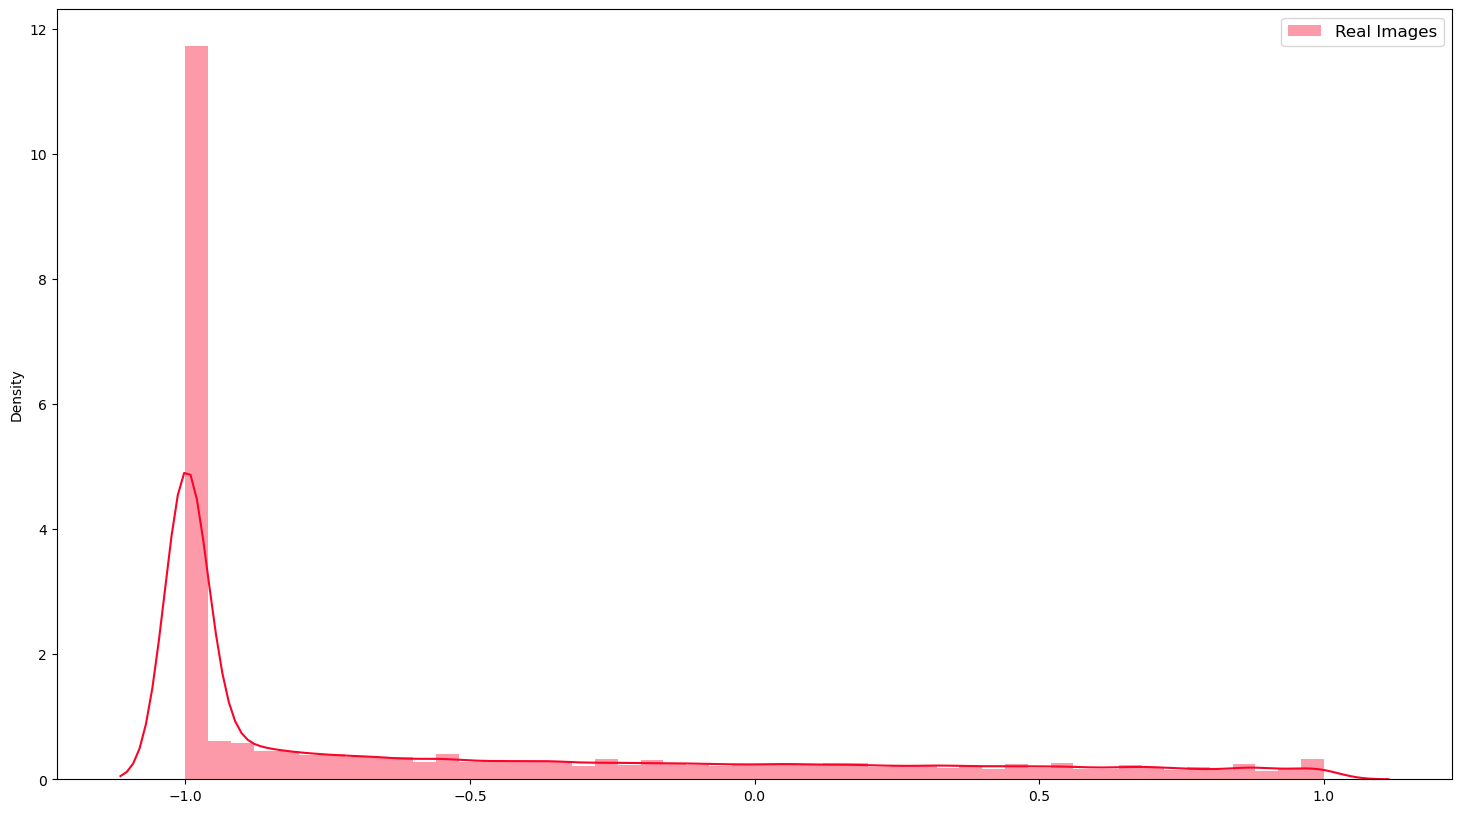

over


In [20]:
print("Class Distribution before augmentation: ")

def Augmentation_framework(CLASSIC_AUG, GAN_AUG, MIXUP_AUG, Images, Labels, y_val):

    if CLASSIC_AUG == True:
        print("---------------- Classic Augmentation ----------------")
        Glioma_Images, Glioma_Labels= classic_augmentation(data_to_augment[0], label_to_augment[0], 'yes')
        print("Glioma_Images: ", Glioma_Images.shape)
        print("Glioma_Labels: ", Glioma_Labels.shape)

        Menin_Images, Menin_Labels= classic_augmentation(data_to_augment[1], label_to_augment[1], 'no')
        print("Menin_Images: ", Menin_Images.shape)
        print("Menin_Labels: ", Menin_Labels.shape)
        
        Pit_Images, Pit_Labels= classic_augmentation(data_to_augment[1], label_to_augment[1], 'pituitary')
        print("Pit_Images: ", Pit_Images.shape)
        print("Pit_Labels: ", Pit_Labels.shape)

        # Combine the classically augmented classes to the rest of the x_train
        Images = np.concatenate((Images, Menin_Images, Glioma_Images, Pit_Images), axis=0)
        Labels = np.concatenate((Labels, Menin_Labels, Glioma_Labels, Pit_Labels), axis=0)

        del Menin_Images
        del Menin_Labels
        del Glioma_Images
        del Glioma_Labels
        del Pit_Images
        del Pit_Labels
        gc.collect()


    if MIXUP_AUG == True:
        print("---------------- Mix Up Augmentation ----------------")
        mixup_images, mixup_labels = MixUp(Images, Labels)
        print(f"augmented_train_images: {mixup_images.shape}, augmented_train_labels: {mixup_labels.shape}")

        le = LabelEncoder()
        Labels = le.fit_transform(y_train)
        Labels = to_categorical(y_train)

        Images = np.concatenate((x_train, mixup_images), axis=0)
        print("Train Images Set After Mixup Augmentation: ", Images.shape)

        Labels = np.concatenate((Labels, mixup_labels), axis=0)
        print("Train Labels Set After Mixup Augmentation: ", Labels.shape)

        le = LabelEncoder()
        y_val = le.fit_transform(y_val)
        y_val = to_categorical(y_val)

        del mixup_images
        del mixup_labels
        gc.collect()
    
    else:
        le = LabelEncoder()
        Labels = le.fit_transform(Labels)
        Labels = to_categorical(Labels)

        le = LabelEncoder()
        y_val = le.fit_transform(y_val)
        y_val = to_categorical(y_val)
        visualize_distribution(Images, None, 20)
    print("over")

    return Images, Labels, y_val

Images, Labels, y_val = Augmentation_framework(CLASSIC_AUG, GAN_AUG, MIXUP_AUG, x_train, y_train, y_val)
    

# Data generator initialization

In [21]:
def init_data():
    
    train_datagen = ImageDataGenerator()
    val_datagen = ImageDataGenerator()
    test_datagen = ImageDataGenerator()

    train_data = train_datagen.flow(Images,
                                     Labels, 
                                     shuffle= True,
                                     seed= 22, 
                                     batch_size= BATCH_SIZE)
    valid_data = val_datagen.flow(x_val, 
                                   y_val, 
                                   shuffle= True,
                                   seed= 22,
                                   batch_size= BATCH_SIZE)
    test_data = test_datagen.flow(x_test,
                                   y_test,
                                   shuffle= True,
                                   seed= 22,
                                   batch_size= BATCH_SIZE)

    return train_data, valid_data, test_data


# Training

In [22]:
def train():
    config={
    "dropout_1": 0.2,
    "dropout_2": 0.2,        
    "activation_1": "relu",
    "activation_2": "sigmoid", 
    "optimizer": "Adamax",
    "decay_rate": 0.5,
    "loss": "Binary_Crossentropy", 
    "metric_Acc": "accuracy",
    "epoch": 30,
    "batch_size": 32,
    "nodes": 256,
    "learning_rate": 0.01,
    "layer_num": 1,
    "GAN_Aug": False,
    "Mixup_Aug": False,
    "Classic_Aug": False,
    "tf_model": 'IRV2',
    "Enhanced": True,
    "Dataset": "Dataset 3",
    'Image_size': 128,
    'Data_Split': '80:10:10'
    }
  
    train_data, valid_data, test_data= init_data()
    n_samples_train = len(train_data)*(32)
    print("n_samples_train: ", n_samples_train)
    n_samples_val = len(valid_data)*(32)
    print("n_samples_val: ", n_samples_val)
    n_samples_test = len(test_data)*(32)
    print("n_samples_val: ", n_samples_test)

        
    def build_transfer_learning_model(base_model):
        # base_model.summary()
        # tf.keras.utils.plot_model(base_model, to_file=f"{CODE_OUTPUTS}rad_model.png", dpi= 300,  show_shapes=True)

        # `base_model` stands for the pretrained model
        # We want to use the learned weights, and to do so we must freeze them
        for layer in base_model.layers:
            layer.trainable = False
#         print(base_model.layers[171:])
        for layer in base_model.layers[:-8]:
            layer.trainable = False
        for layer in base_model.layers[-8:]:
            layer.trainable = True


        model = tf.keras.Sequential([
            base_model,
            Flatten(),
            Dense(units=config.nodes, activation= config.activation_1),            
            Dense(units=2, activation=config.activation_2)
        ])

        # Compile the model
        model.compile(
            loss= 'binary_crossentropy',
            optimizer=Adam(config.learning_rate),
            metrics=[config.metric_Acc, 
                     TopKCategoricalAccuracy(k= 2, name='Top2_Acc'), 
                     AUC(multi_label= True, num_labels= 2), 
                     Precision(thresholds=0.6), 
                     Recall(thresholds=0.2),
                     TruePositives(), 
                     FalsePositives(), 
                     TrueNegatives(), 
                     FalseNegatives()
                    ])

        return model
    rad_model = build_transfer_learning_model(
    base_model = InceptionResNetV2(weights= model_dir, input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),  include_top=False)
    )

    rad_model.summary()
    callbacks = [ReduceLROnPlateau(monitor='val_accuracy', factor=0.2, patience=4, min_lr=0.0001),
                PRMetrics(valid_data, train_data, num_log_batches= 32), 
                csv_logger
                ]

    
    rad_hist = rad_model.fit(
    train_data,
    validation_data= valid_data,
    steps_per_epoch= n_samples_train// config.batch_size,
    validation_steps= n_samples_val// config.batch_size,
    epochs=config.epoch,
    callbacks= callbacks
    
    )
    return rad_model, rad_hist, valid_data, test_data


# Extrac Metrics

In [23]:
class PRMetrics(Callback):
  """ Custom callback to compute per-class PR & ROC curves
  at the end of each training epoch"""
  def __init__(self, generator=None, trainer= None, tester= None, num_log_batches=1):
    self.generator = generator
    self.trainer= trainer
    self.num_batches = num_log_batches
    self.val_f1s = []
    self.val_recalls = []
    self.val_precisions = []
    self.class_names= {0: 'yes', 1: 'no'}
    self.flat_class_names = ['yes', 'no']
    

  def on_epoch_end(self, epoch, logs={}):

    val_data, val_labels = self.generator.next()
    train_data, train_labels = self.trainer.next()
    val_predictions = self.model.predict(val_data)
    print(val_predictions.shape)
    ground_truth_class_ids = val_labels.argmax(axis=1)

    wandb.log({"roc_curve" : wandb.plot.roc_curve(ground_truth_class_ids, val_predictions, labels= self.flat_class_names)})
    wandb.log({"precision_curve" : wandb.plot.pr_curve(ground_truth_class_ids, val_predictions, labels= self.flat_class_names)})
    wandb.log({"precision_recall_curve": wandb.sklearn.plot_precision_recall(ground_truth_class_ids, val_predictions, labels= self.flat_class_names)})
    

# Run Training

In [ ]:
rad_model, rad_hist, valid_data, test_data = train()

wandb: Currently logged in as: fleur. Use `wandb login --relogin` to force relogin


n_samples_train:  2400
n_samples_val:  320
n_samples_val:  320
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 inception_resnet_v2 (Functi  (None, 2, 2, 1536)       54336736  
 onal)                                                           
                                                                 
 flatten (Flatten)           (None, 6144)              0         
                                                                 
 dense (Dense)               (None, 256)               1573120   
                                                                 
 dense_1 (Dense)             (None, 2)                 514       
                                                                 
Total params: 55,910,370
Trainable params: 5,703,970
Non-trainable params: 50,206,400
_________________________________________________________________


wandb: WARNING The save_model argument by default saves the model in the HDF5 format that cannot save custom objects like subclassed models and custom layers. This behavior will be deprecated in a future release in favor of the SavedModel format. Meanwhile, the HDF5 model is saved as W&B files and the SavedModel as W&B Artifacts.
wandb: WARNING WandbCallback is unable to log validation data. When using a generator for validation_data, you must pass validation_steps


Epoch 1/30
75/75 [==============================] - ETA: 0s - loss: 1.7436 - accuracy: 0.7883 - Top2_Acc: 1.0000 - auc: 0.8266 - precision: 0.8154 - recall: 0.8929 - true_positives: 1881.0000 - false_positives: 518.0000 - true_negatives: 1882.0000 - false_negatives: 519.0000

wandb: Adding directory to artifact (/kaggle/working/wandb/run-20230425_171926-cucfmpig/files/model-best)... Done. 1.3s


...

1/1 [==============================] - 0s 54ms/step
(32, 2)
75/75 [==============================] - 102s 1s/step - loss: 0.0701 - accuracy: 0.9729 - Top2_Acc: 1.0000 - auc: 0.9968 - precision: 0.9769 - recall: 0.9879 - true_positives: 2333.0000 - false_positives: 65.0000 - true_negatives: 2335.0000 - false_negatives: 67.0000 - val_loss: 0.1219 - val_accuracy: 0.9500 - val_Top2_Acc: 1.0000 - val_auc: 0.9891 - val_precision: 0.9659 - val_recall: 0.9833 - val_true_positives: 286.0000 - val_false_positives: 15.0000 - val_true_negatives: 285.0000 - val_false_negatives: 14.0000 - lr: 0.0100
Epoch 8/30
1/1 [==============================] - 0s 53ms/steploss: 0.0665 - accuracy: 0.9762 - Top2_Acc: 1.0000 - auc: 0.9964 - precision: 0.9806 - recall: 0.9887 - true_positives: 2343.0000 - false_positives: 57.0000 - true_negatives: 2343.0000 - false_negatives: 57.00
(32, 2)
75/75 [==============================] - 6s 84ms/step - loss: 0.0665 - accuracy: 0.9762 - Top2_Acc: 1.0000 - auc: 0.9964 - prec

wandb: Adding directory to artifact (/kaggle/working/wandb/run-20230425_171926-cucfmpig/files/model-best)... Done. 1.2s


1/1 [==============================] - 0s 56ms/step
(32, 2)
75/75 [==============================] - 101s 1s/step - loss: 0.0019 - accuracy: 1.0000 - Top2_Acc: 1.0000 - auc: 1.0000 - precision: 1.0000 - recall: 1.0000 - true_positives: 2400.0000 - false_positives: 0.0000e+00 - true_negatives: 2400.0000 - false_negatives: 0.0000e+00 - val_loss: 0.1138 - val_accuracy: 0.9833 - val_Top2_Acc: 1.0000 - val_auc: 0.9859 - val_precision: 0.9833 - val_recall: 0.9867 - val_true_positives: 295.0000 - val_false_positives: 5.0000 - val_true_negatives: 295.0000 - val_false_negatives: 5.0000 - lr: 0.0020
Epoch 20/30
75/75 [==============================] - ETA: 0s - loss: 9.4583e-04 - accuracy: 1.0000 - Top2_Acc: 1.0000 - auc: 1.0000 - precision: 1.0000 - recall: 1.0000 - true_positives: 2400.0000 - false_positives: 0.0000e+00 - true_negatives: 2400.0000 - false_negatives: 0.0000e+00

wandb: Adding directory to artifact (/kaggle/working/wandb/run-20230425_171926-cucfmpig/files/model-best)... Done. 1.4s


1/1 [==============================] - 0s 52ms/step
(12, 2)
75/75 [==============================] - 102s 1s/step - loss: 9.4583e-04 - accuracy: 1.0000 - Top2_Acc: 1.0000 - auc: 1.0000 - precision: 1.0000 - recall: 1.0000 - true_positives: 2400.0000 - false_positives: 0.0000e+00 - true_negatives: 2400.0000 - false_negatives: 0.0000e+00 - val_loss: 0.1100 - val_accuracy: 0.9867 - val_Top2_Acc: 1.0000 - val_auc: 0.9861 - val_precision: 0.9867 - val_recall: 0.9867 - val_true_positives: 296.0000 - val_false_positives: 4.0000 - val_true_negatives: 296.0000 - val_false_negatives: 4.0000 - lr: 0.0020
Epoch 21/30
1/1 [==============================] - 0s 51ms/steploss: 8.6330e-04 - accuracy: 1.0000 - Top2_Acc: 1.0000 - auc: 1.0000 - precision: 1.0000 - recall: 1.0000 - true_positives: 2400.0000 - false_positives: 0.0000e+00 - true_negatives: 2400.0000 - false_negatives: 0.0000e+
(32, 2)
75/75 [==============================] - 6s 84ms/step - loss: 8.6330e-04 - accuracy: 1.0000 - Top2_Acc: 1.00

## The End